# Electricity Theft Detection

Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv('dataset.csv')
df.head()

,FLAG,mean_consumption,std_consumption,cv,num_zeros,trend_slope,sudden_drop_count,min_consumption,max_consumption,median_consumption,num_below_mean,skewness,iqr,max_drop_pct
0,1.0,13.898342,6.683785,0.480905,0,-0.000364,46,2.46,46.49,13.898342,811,1.513367,5.095842,0.926731
1,1.0,0.000000,0.000000,0.000000,1034,0.000000,0,0.00,0.00,0.000000,0,0.000000,0.000000,0.000000
2,1.0,9.921390,3.409611,0.343663,41,-0.000358,15,0.00,32.81,9.921390,160,1.976875,0.000000,1.000000
3,1.0,14.612055,7.712976,0.527850,0,0.012225,56,0.40,52.76,14.612055,266,0.984226,0.399555,0.992418
4,1.0,8.249738,5.930837,0.718912,0,0.010040,51,0.85,43.43,6.280000,694,2.597712,5.197500,0.750733


In [2]:
df.shape

(77510, 14)

In [3]:
df['FLAG'].value_counts()

FLAG
1.0    38755
0.0    38755
Name: count, dtype: int64

In [4]:
df.columns

Index(['FLAG', 'mean_consumption', 'std_consumption', 'cv', 'num_zeros',
       'trend_slope', 'sudden_drop_count', 'min_consumption',
       'max_consumption', 'median_consumption', 'num_below_mean', 'skewness',
       'iqr', 'max_drop_pct'],
      dtype='object')

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77510 entries, 0 to 77509
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   FLAG                77510 non-null  float64
 1   mean_consumption    77510 non-null  float64
 2   std_consumption     77510 non-null  float64
 3   cv                  77510 non-null  float64
 4   num_zeros           77510 non-null  int64  
 5   trend_slope         77510 non-null  float64
 6   sudden_drop_count   77510 non-null  int64  
 7   min_consumption     77510 non-null  float64
 8   max_consumption     77510 non-null  float64
 9   median_consumption  77510 non-null  float64
 10  num_below_mean      77510 non-null  int64  
 11  skewness            77510 non-null  float64
 12  iqr                 77510 non-null  float64
 13  max_drop_pct        77510 non-null  float64
dtypes: float64(11), int64(3)
memory usage: 8.3 MB


,FLAG,mean_consumption,std_consumption,cv,num_zeros,trend_slope,sudden_drop_count,min_consumption,max_consumption,median_consumption,num_below_mean,skewness,iqr,max_drop_pct
count,77510.000000,77510.000000,77510.000000,77510.000000,77510.000000,7.751000e+04,77510.000000,77510.000000,77510.000000,77510.000000,77510.000000,77510.000000,77510.000000,7.751000e+04
mean,0.500000,5.436582,4.678636,2.503126,84.363450,8.499946e-04,224.129661,0.592655,88.652445,5.039173,557.673565,1.716778,2.084911,1.221300e+03
std,0.500003,60.853419,170.379895,99.754553,233.254399,3.308053e-02,194.474939,12.521312,5440.174259,60.111240,193.310248,4.196594,17.528148,2.947389e+04
min,0.000000,-0.002669,0.000000,-8397.004764,0.000000,-4.973759e+00,0.000000,-0.189850,0.000000,-0.002485,0.000000,-25.649301,0.000000,0.000000e+00
25%,0.000000,0.000570,0.001286,0.412250,0.000000,-3.155461e-07,45.000000,-0.002979,0.005710,0.000465,518.250000,0.123669,0.001768,1.000000e+00
50%,0.500000,0.064505,0.101631,0.952970,0.000000,3.451109e-07,118.000000,0.000000,1.250000,0.005329,529.000000,0.447339,0.002431,1.000000e+00
75%,1.000000,6.360850,2.988464,2.309550,10.000000,4.497437e-04,439.000000,0.000000,25.010000,5.845000,627.000000,1.739536,1.922127,3.351987e+02
max,1.000000,13601.100000,24875.641596,13205.564828,1034.000000,3.298980e+00,595.000000,3234.000000,800003.320000,13601.100000,1033.000000,32.155825,3094.500000,5.344238e+06


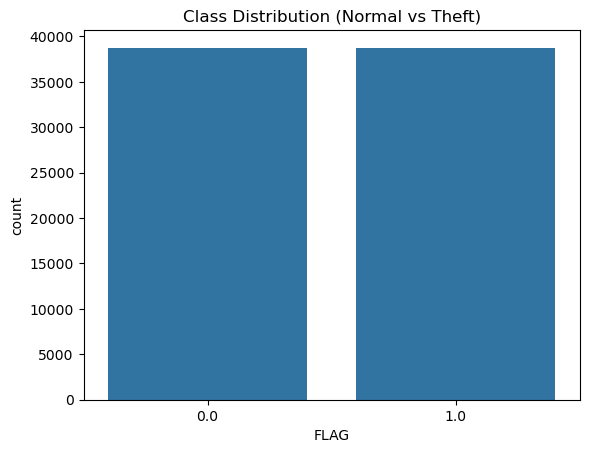

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='FLAG', data=df)
plt.title("Class Distribution (Normal vs Theft)")
plt.show()


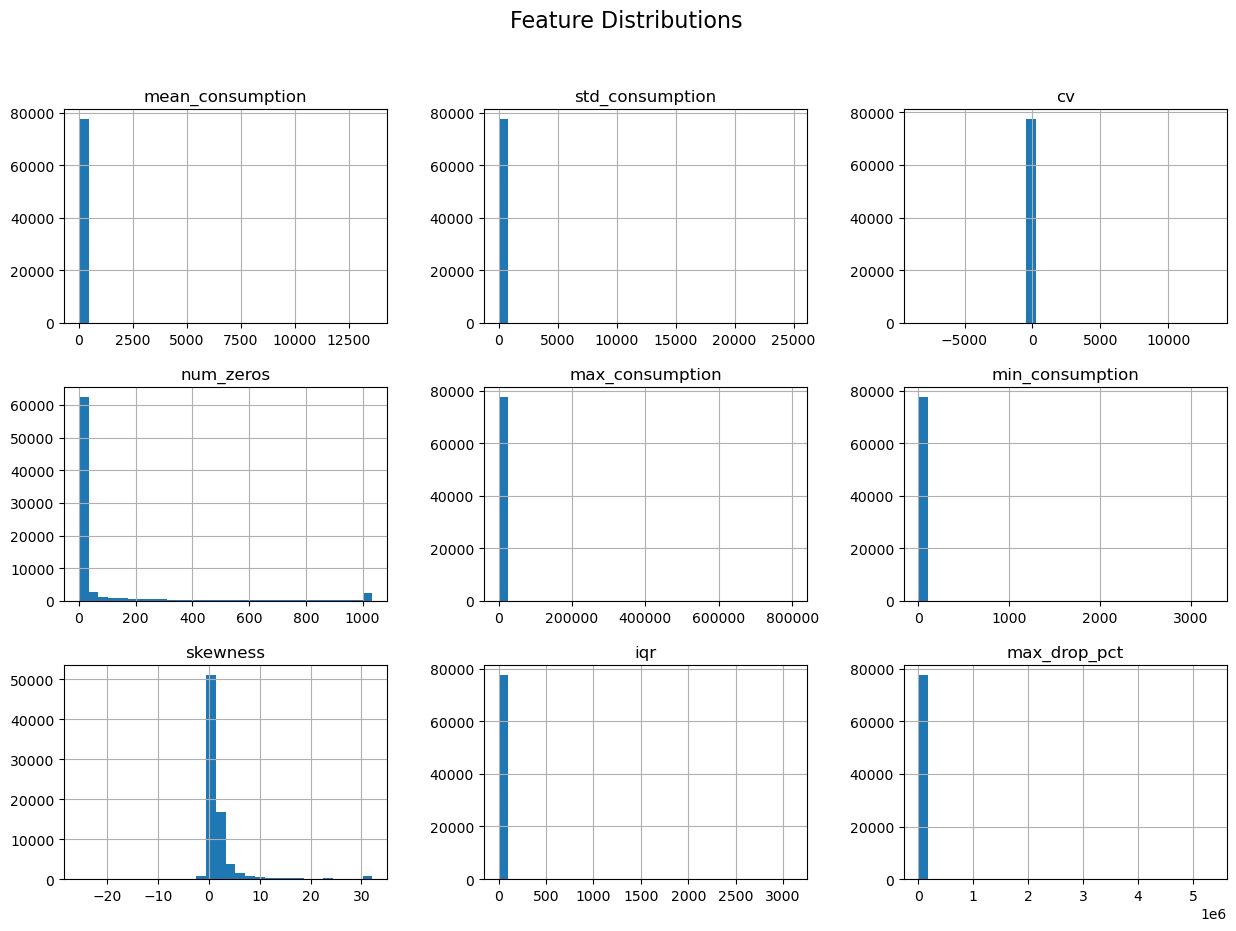

In [7]:
features = [
    'mean_consumption', 'std_consumption', 'cv',
    'num_zeros', 'max_consumption', 'min_consumption',
    'skewness', 'iqr', 'max_drop_pct'
]

df[features].hist(bins=30, figsize=(15,10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


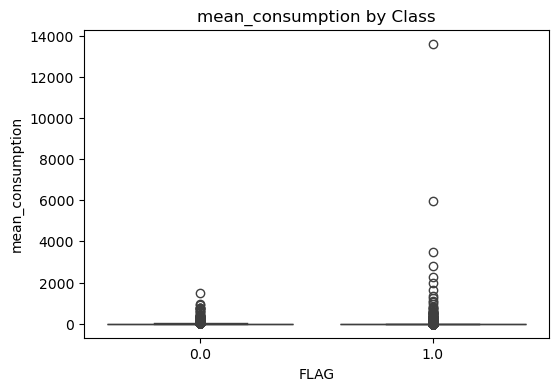

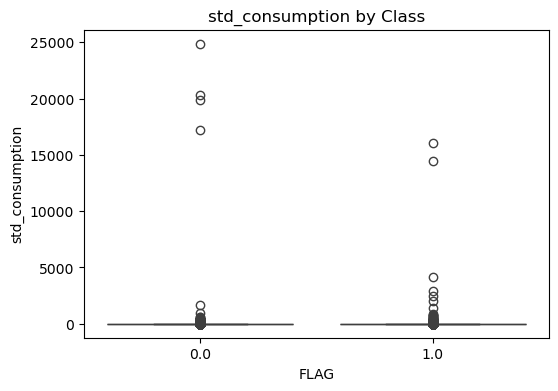

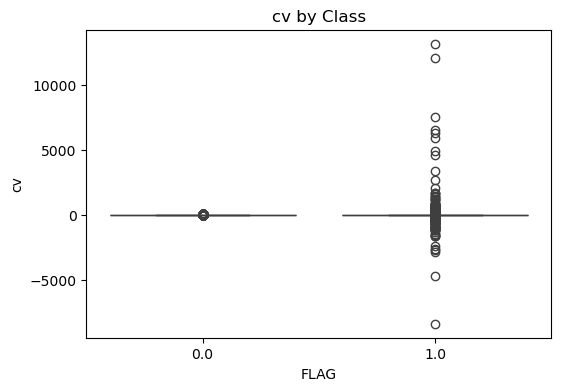

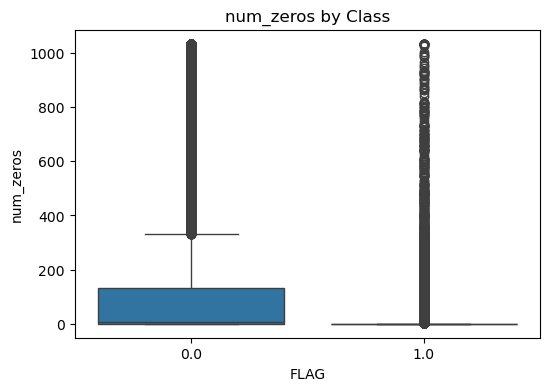

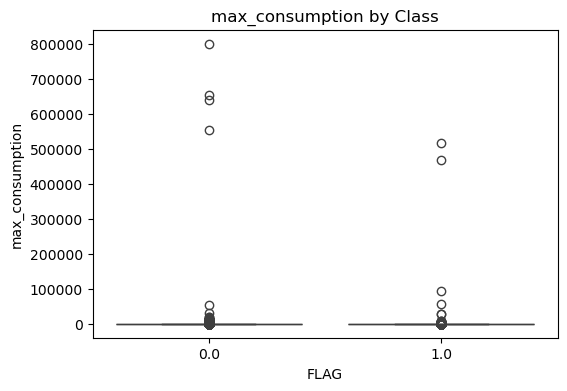

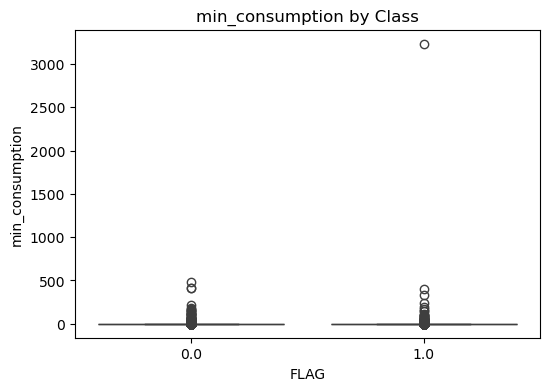

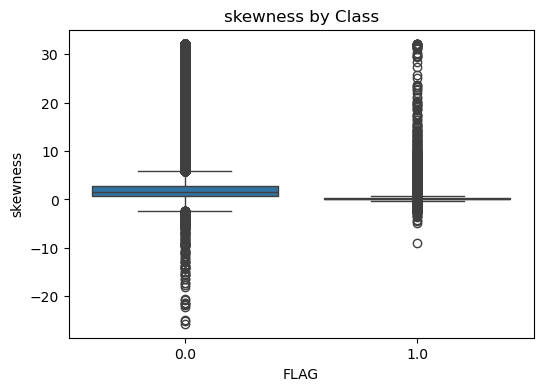

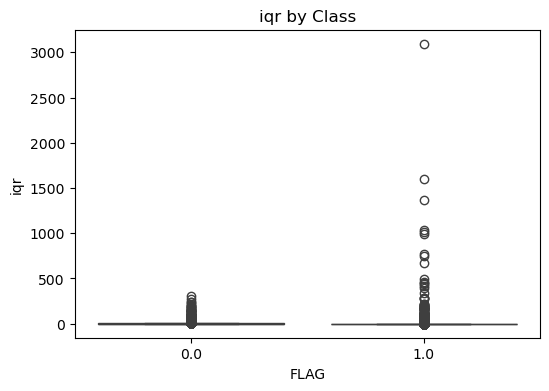

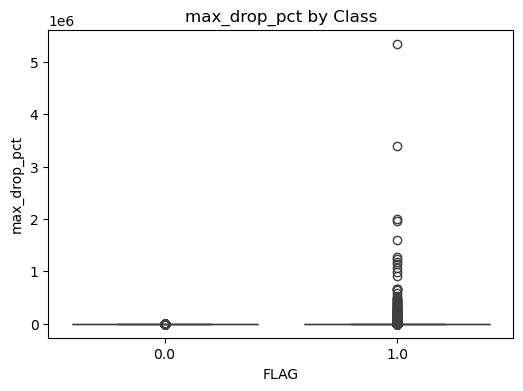

In [8]:
for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='FLAG', y=col, data=df)
    plt.title(f"{col} by Class")
    plt.show()


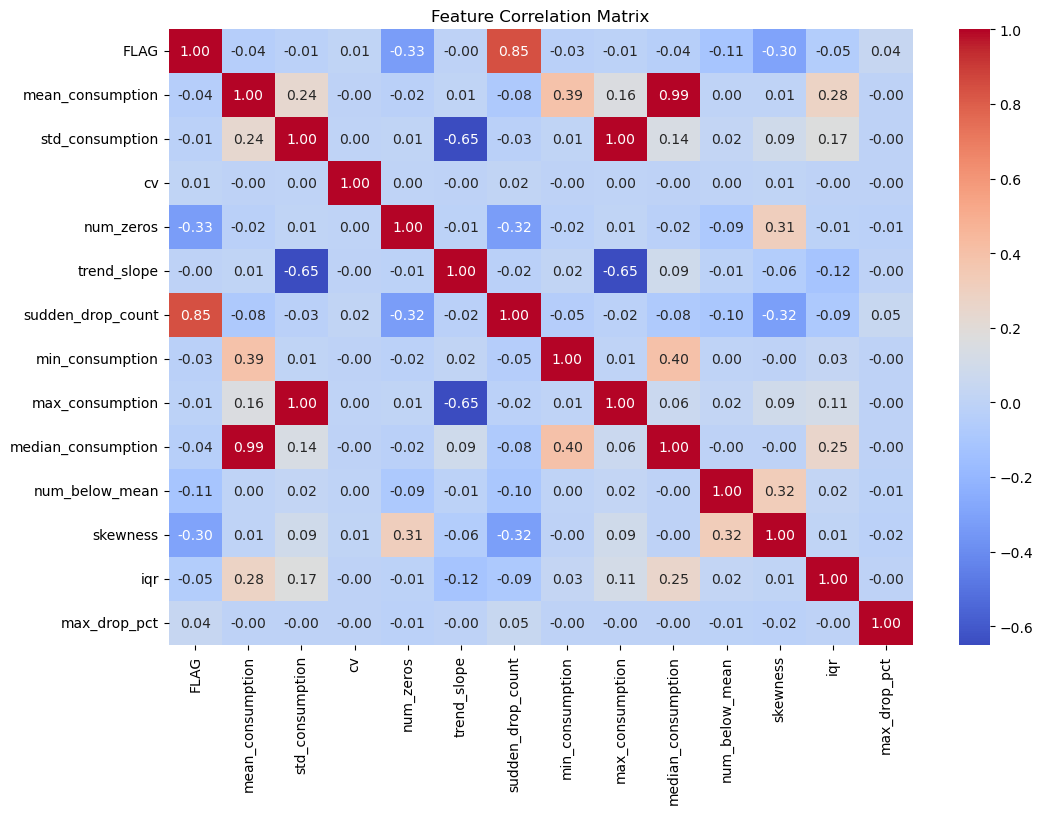

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


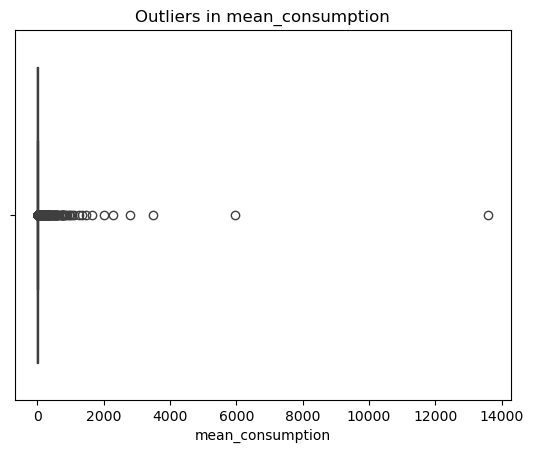

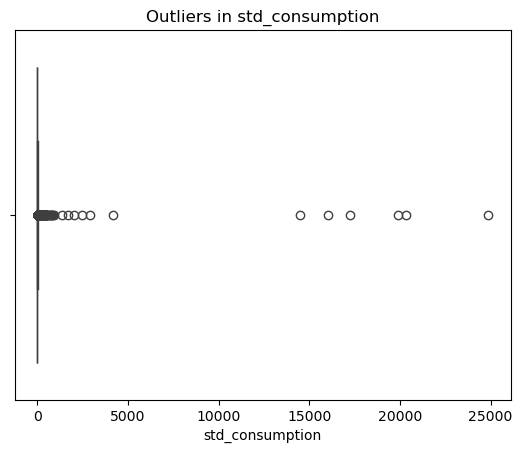

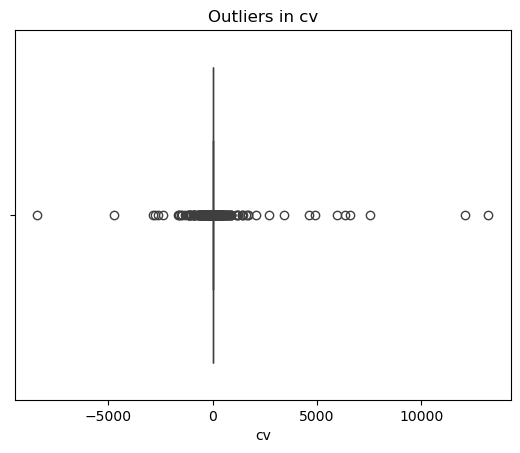

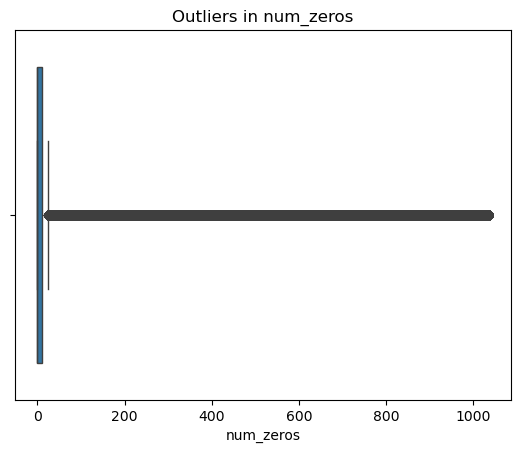

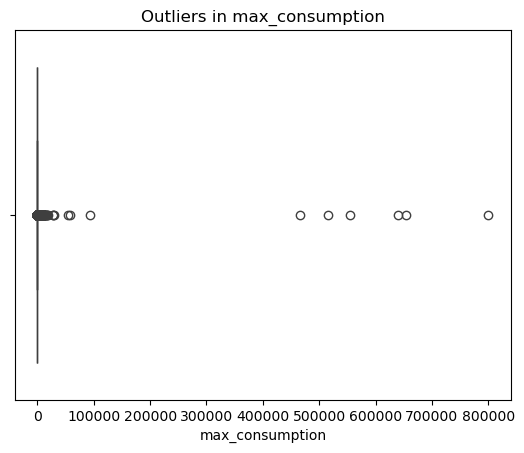

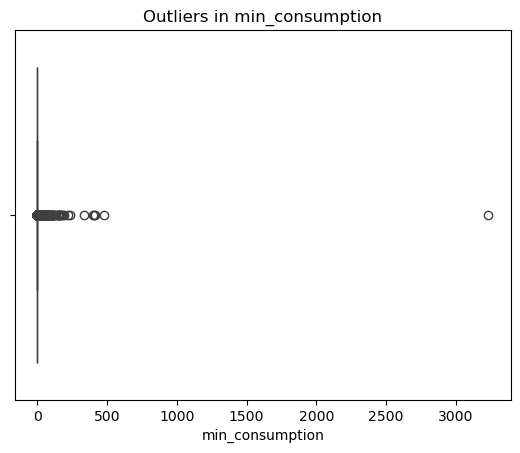

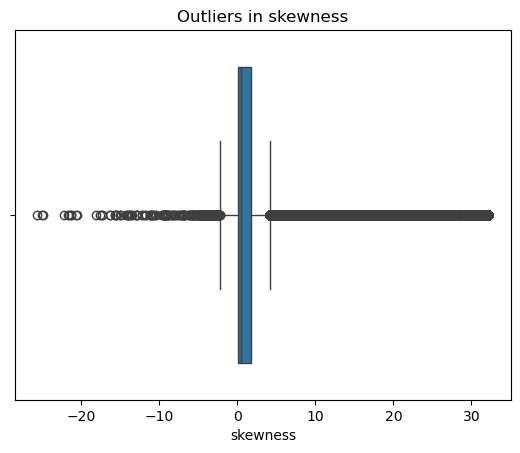

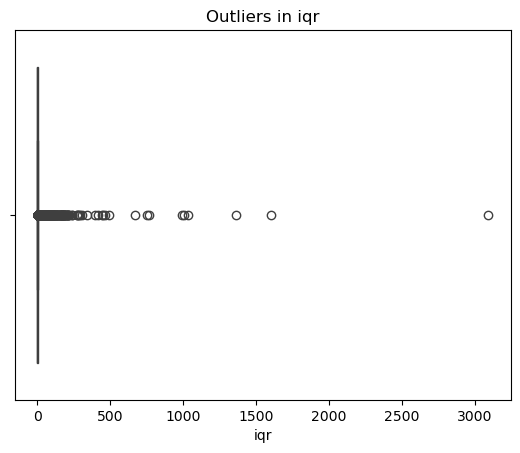

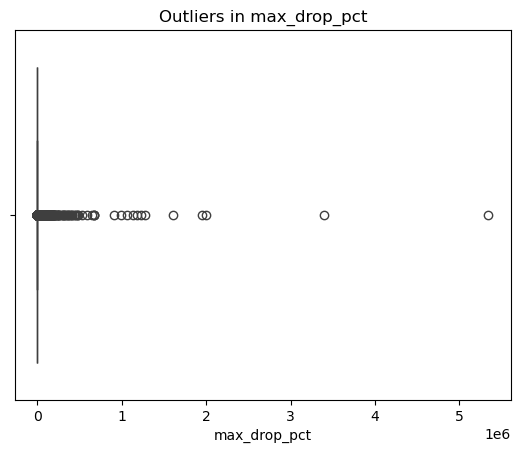

In [10]:
df.groupby('FLAG').mean()
for col in features:
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()
